## Comparison of historical event in ERA5 CESM2 resolution vs original (ERA5) resolution
### Fig 9 (Supplement)

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature
import glob
from datetime import date, timedelta
from matplotlib import rcParams

In [2]:
rcParams['font.size'] = 20

#file locs
file_loc_1 = '/div/no-backup-nac/reanalysis/ERA-5/day'
land_mask_fileloc = '/div/nac/users/zofias/CESM_output/land_mask/Norway_mask_192_288_CESM2-LENS.nc'


In [3]:
#selects lat lon bounds for region for plotting
#regions = {'SA': [5,35,65,95],'EA' : [20,53,95,133],'NA' : [25,70,-150,-45], 'EU' : [35,70,-20,45],'NO' : [53,72,0,32],'NO_ext': [50,80,-30,37]}

lat_min, lat_max, lon_min, lon_max = [53,72,0,32]

In [4]:
#*****pick event date to look at*****
# E.g. Hans (2023,8,8), Nuvsvåg (2025,9,25)

selected_date = date(2023,8,8)

start_date = (selected_date - timedelta(days=5)).strftime("%Y-%m-%d")
end_date = (selected_date + timedelta(days=5)).strftime("%Y-%m-%d")
event_date = selected_date.strftime("%Y-%m-%d")

In [5]:
#read in data, select only overlap period between ERA5 adn CESM2LENS (SSP370)
era5_data_cesmres = xr.open_dataset(f'{file_loc_1}/regridded_to_CESM2LENS/precipTOT_day_ERA5_20100101-20241231_CESMLENSgrid.nc').sel(valid_time=slice(start_date,end_date))

era5_data_origres = xr.open_dataset(f'{file_loc_1}/pr_day_ERA5_20100101-20241231.nc').sel(valid_time=slice(start_date,end_date)).sel(longitude=slice(lon_min,lon_max),latitude=slice(lat_max,lat_min))
era5_data_origres = era5_data_origres.rename({'valid_time':'time','latitude':'lat','longitude':'lon'})
era5_data_cesmres = era5_data_cesmres.rename({'valid_time':'time'})


#land mask
land_percent_data = xr.open_dataset(land_mask_fileloc)
land_percent_data = land_percent_data.assign_coords(lon=(((land_percent_data.lon + 180) % 360) - 180)).sortby('lon')
land_mask = land_percent_data.mask


In [6]:
#units are in m (daily), convert to mm/day
era5_data_cesmres['tp'] = era5_data_cesmres['tp'] * 1000
era5_data_cesmres["tp"] = era5_data_cesmres.tp.assign_attrs(long_name = "Total precipitation", units='mm/day',cell_methods = "time: sum")

era5_data_origres['tp'] = era5_data_origres['tp'] * 1000
era5_data_origres["tp"] = era5_data_origres.tp.assign_attrs(long_name = "Total precipitation", units='mm/day',cell_methods = "time: sum")

In [7]:
era5_data_origres

<xarray.Dataset>
Dimensions:  (time: 11, lon: 129, lat: 77)
Coordinates:
  * time     (time) datetime64[ns] 2023-08-03 2023-08-04 ... 2023-08-13
  * lon      (lon) float64 0.0 0.25 0.5 0.75 1.0 ... 31.0 31.25 31.5 31.75 32.0
  * lat      (lat) float64 72.0 71.75 71.5 71.25 71.0 ... 53.75 53.5 53.25 53.0
Data variables:
    tp       (time, lat, lon) float32 13.77 14.57 15.45 ... 4.883 4.309 3.795
Attributes:
    CDI:                     Climate Data Interface version 2.1.1 (https://mp...
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    history:                 Tue Oct 07 08:28:41 2025: cdo mergetime download...
    CDO:                     Climate Data Operators version 2.1.1 (https://mp...

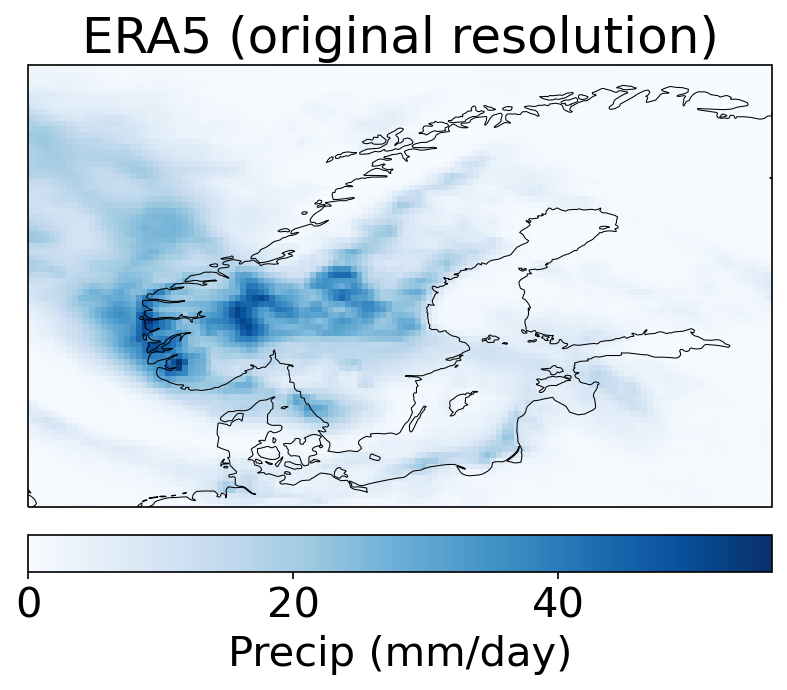

In [8]:
#Plot event on ERA5 native resolution
fig, axis = plt.subplots(1, 1, dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))
fg = era5_data_origres['tp'].sel(time=event_date).plot(cmap='Blues',
                                                       #vmax=40,
    cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
    xlim=(lon_min,lon_max),
    ylim=(lat_min,lat_max),
    )

plt.title(f"ERA5 (original resolution)")
axis.coastlines(linewidth=0.5)  # cartopy function
#axis.add_feature(cartopy.feature.OCEAN,facecolor=("aliceblue"))

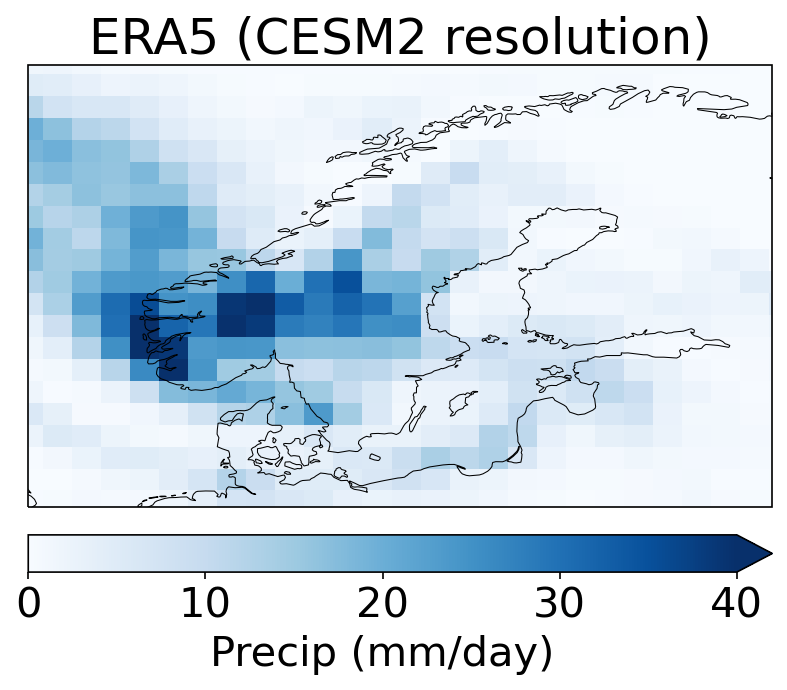

In [10]:
#Plot event on CESM2 resolution
fig, axis = plt.subplots(1, 1, dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))
fg = era5_data_cesmres['tp'].sel(time=event_date).plot(cmap='Blues',
                                                       vmax=40,
    cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
    xlim=(lon_min,lon_max),
    ylim=(lat_min,lat_max),
    )

plt.title(f"ERA5 (CESM2 resolution)")
axis.coastlines(linewidth=0.5)  # cartopy function
#axis.add_feature(cartopy.feature.OCEAN,facecolor=("aliceblue"))

In [11]:
#mask array, anything not land has data = nan
#doesnt work for ERA5 org data because need a land mask at correct resolution
#era5_data_origres['PRECT_land'] = era5_data_origres['tp'].where(land_mask)
era5_data_cesmres['PRECT_land'] = era5_data_cesmres['tp'].where(land_mask)

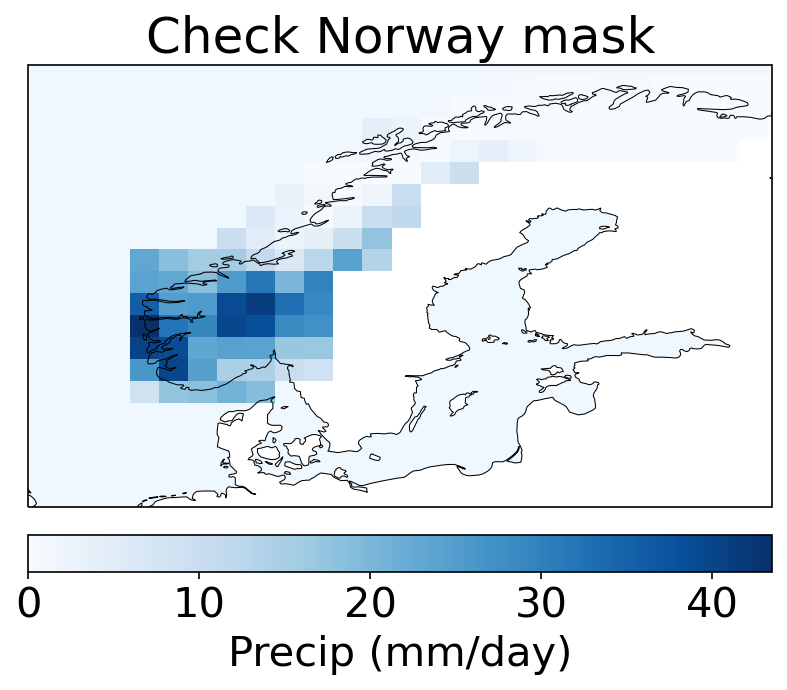

In [12]:
#Check land mask on map plot
fig, axis = plt.subplots(1, 1, dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))
fg = era5_data_cesmres['PRECT_land'].sel(time=event_date).plot(cmap='Blues',
    cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05},
    xlim=(lon_min,lon_max),
    ylim=(lat_min,lat_max),
    )

plt.title(f"Check Norway mask")
axis.coastlines(linewidth=0.5)  # cartopy function
axis.add_feature(cartopy.feature.OCEAN,facecolor=("aliceblue"))

In [ ]:
#maximum precip value for event date, over land (CESM2 resolution)
print(era5_data_cesmres['PRECT_land'].sel(time=event_date).max())

<xarray.DataArray 'PRECT_land' ()>
array(43.52584457)
Coordinates:
    time     datetime64[ns] 2023-08-08


In [15]:
#maximum precip value in ERA5 resolution
print(era5_data_origres['tp'].sel(time=event_date).max())

<xarray.DataArray 'tp' ()>
array(56.15901947)
Coordinates:
    time     datetime64[ns] 2023-08-08


In [ ]:
#5day rolling mean, maximum (CESM2 resolution)
precip5day = era5_data_cesmres['PRECT_land'].rolling(time=5,min_periods=5,center=True).sum(skipna=True)
print(precip5day.max())

<xarray.DataArray 'PRECT_land' ()>
array(114.52143097)
